In [31]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

In [22]:
datos = load_breast_cancer()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
df['target'] = datos.target

In [23]:
print("Dimensiones: ", df.shape)
print("Clases: ", datos.target_names)

print("Valores faltantes:")
print(df.isnull().sum())

print("Duplicados")
print(df.duplicated().sum())

print("Distribucion de la variable objetivo:")
print(df['target'].value_counts())

print("Distribucion porcentual:")
print(df['target'].value_counts(normalize=True))

Dimensiones:  (569, 31)
Clases:  ['malignant' 'benign']
Valores faltantes:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
Duplicados
0


2

In [24]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

3

In [33]:
start_time_base = time.time()
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
time_base = time.time() - start_time_base

y_pred_base = rf_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base, pos_label=0)

4-5

In [26]:
selector = SelectFromModel(rf_base, threshold="mean", prefit=True)
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


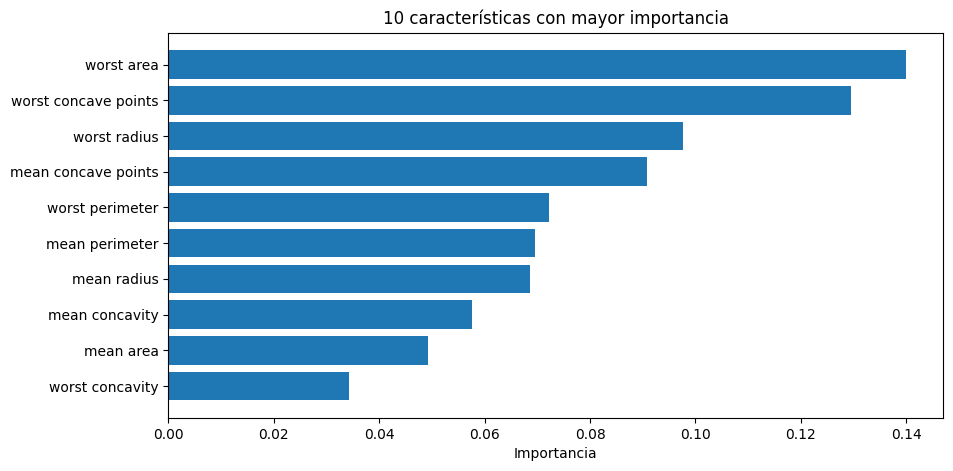

In [32]:
importancias = rf_base.feature_importances_
indices_top10 = np.argsort(importancias)[::-1][:10]
nombres_top10 = [X.columns[i] for i in indices_top10]

plt.figure(figsize=(10, 5))
plt.barh(range(10), importancias[indices_top10][::-1])
plt.yticks(range(10), nombres_top10[::-1])
plt.xlabel('Importancia')
plt.title('10 características con mayor importancia')
plt.show()

6

In [36]:
start_time_reduced = time.time()
rf_reduced = RandomForestClassifier(random_state=42)
rf_reduced.fit(X_train_reduced, y_train)
time_reduced = time.time() - start_time_reduced

y_pred_reduced = rf_reduced.predict(X_test_reduced)
acc_reduced = accuracy_score(y_test, y_pred_reduced)
recall_reduced = recall_score(y_test, y_pred_reduced, pos_label=0)

print(f"Entrenamiento original: {X_train.shape}")
print(f"Entrenamiento reducido: {X_train_reduced.shape}")
print(f"Prueba original: {X_test.shape}")
print(f"Prueba reducida: {X_test_reduced.shape}")

Entrenamiento original: (455, 30)
Entrenamiento reducido: (455, 10)
Prueba original: (114, 30)
Prueba reducida: (114, 10)


7

In [39]:
rf_reduced = RandomForestClassifier(random_state=42)

inicio = time.perf_counter()
rf_reduced.fit(X_train_reduced, y_train)
tiempo_reducido = time.perf_counter() - inicio

y_pred_reduced = rf_reduced.predict(X_test_reduced)

acc_reduced = accuracy_score(y_test, y_pred_reduced)
recall_reduced = recall_score(y_test, y_pred_reduced, pos_label=0)

print("Accuracy:", round(acc_reduced, 4))
print("Recall maligno:", round(recall_reduced, 4))
print("Características:", X_train_reduced.shape[1])
print("Tiempo:", round(tiempo_reducido, 4), "segundos")

Accuracy: 0.9561
Recall maligno: 0.9286
Características: 10
Tiempo: 0.4159 segundos


8

In [40]:
best_rf = grid_search.best_estimator_

y_pred_opt_inv = best_rf.predict(X_test_reduced)
y_pred_opt = 1 - y_pred_opt_inv

acc_opt = accuracy_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt, pos_label=0)
conf_matrix = confusion_matrix(y_test, y_pred_opt)

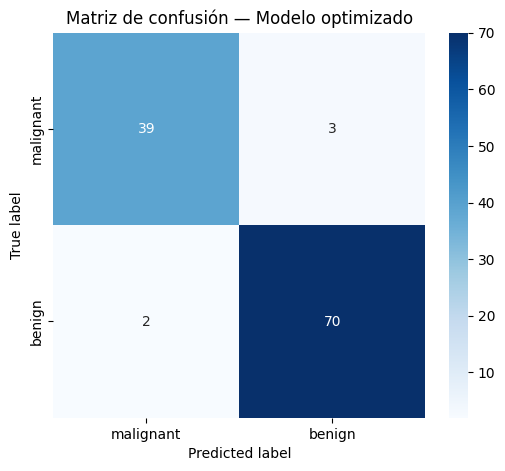

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['malignant', 'benign'],
            yticklabels=['malignant', 'benign'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Matriz de confusión — Modelo optimizado')
plt.show()

9

In [30]:
print(f"Modelo Base       -> Accuracy: {acc_base:.4f}, Recall maligno: {recall_base:.4f}, Características: {X_train.shape[1]}, Tiempo: {time_base:.3f}s")
print(f"Modelo Reducido   -> Accuracy: {acc_reduced:.4f}, Recall maligno: {recall_reduced:.4f}, Características: {X_train_reduced.shape[1]}, Tiempo: {time_reduced:.3f}s")
print(f"Modelo Optimizado -> Accuracy: {acc_opt:.4f}, Recall maligno: {recall_opt:.4f}, Características: {X_train_reduced.shape[1]}, Tiempo: {time_opt:.3f}s")
print(f"\nMatriz de confusión - Modelo Optimizado:\n{conf_matrix}")

Modelo Base       -> Accuracy: 0.9561, Recall maligno: 0.9286, Características: 30, Tiempo: 0.449s
Modelo Reducido   -> Accuracy: 0.9561, Recall maligno: 0.9286, Características: 10, Tiempo: 0.416s
Modelo Optimizado -> Accuracy: 0.9561, Recall maligno: 0.9286, Características: 10, Tiempo: 26.395s

Matriz de confusión - Modelo Optimizado:
[[39  3]
 [ 2 70]]


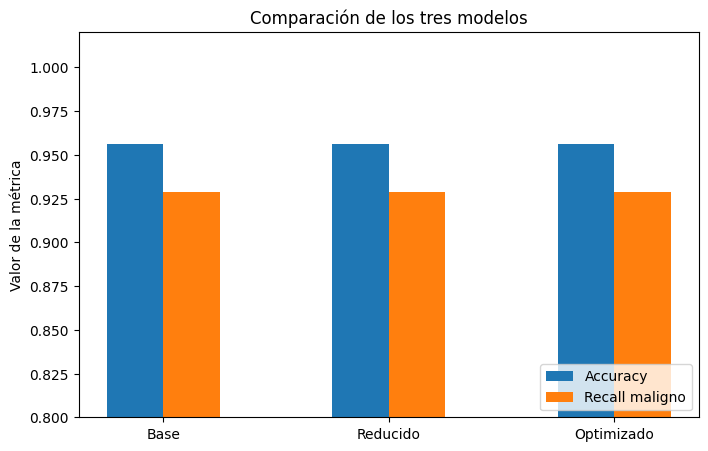

In [35]:
modelos = ['Base', 'Reducido', 'Optimizado']
accuracies = [acc_base, acc_reduced, acc_opt]
recalls = [recall_base, recall_reduced, recall_opt]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy')
ax.bar(x + width/2, recalls, width, label='Recall maligno')

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de los tres modelos')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim([0.800, 1.020])
ax.legend(loc='lower right')
plt.show()